# **Oasis Infobyte Internship**

## **Data Analytics Internship**

### **Task 3: Sales Prediction using Linear Regression**

**Submitted by:** Yasashvi Agarwal

**Domain:** Data Analytics

**Organization:** Oasis Infobyte

## Objective

The objective of this project is to predict product sales based on advertising expenditure using Linear Regression. By analyzing the relationship between advertising channels and sales, businesses can make better marketing decisions and optimize their advertising budget.

## 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline

In [2]:
!wget -O advertising.csv https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv

--2026-07-25 10:37:41--  https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4756 (4.6K) [text/plain]
Saving to: ‘advertising.csv’

advertising.csv     100%[===================>]   4.64K  --.-KB/s    in 0s      

2026-07-25 10:37:41 (33.0 MB/s) - ‘advertising.csv’ saved [4756/4756]



## 2. Load the Dataset

In [3]:
data = pd.read_csv("advertising.csv")
data

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


## 3. Display First Five Rows

In [4]:
data.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## 4. Dataset Information

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


## 5. Dataset Shape

In [6]:
print("Dataset Shape:", data.shape)

Dataset Shape: (200, 5)


## 6. Missing Values

In [7]:
data.isnull().sum()

,0
Unnamed: 0,0
TV,0
radio,0
newspaper,0
sales,0


## 7. Duplicate Values

In [8]:
print("Duplicate Rows:", data.duplicated().sum())

Duplicate Rows: 0


## 8. Statistical Summary

In [9]:
data.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


## 9. Exploratory Data Analysis (EDA)

### 9.1 Sales Distribution

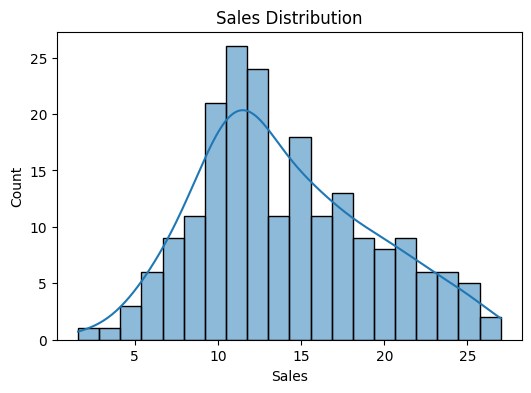

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(data['sales'], bins=20, kde=True)
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Count')
plt.show()

**Observation:**

- Sales values are distributed across different ranges.
- Most sales values are concentrated around the middle range.
- The distribution appears approximately normal with slight variation.

### 9.2 TV Advertising vs Sales

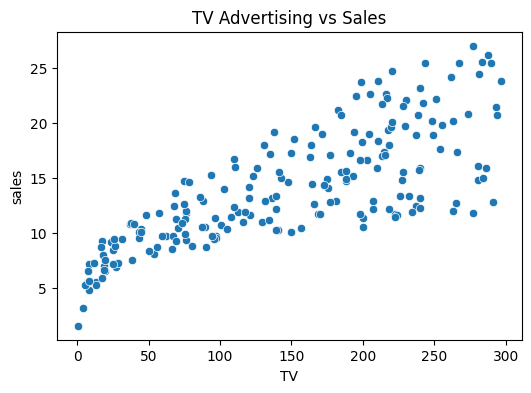

In [11]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='TV', y='sales', data=data)
plt.title('TV Advertising vs Sales')
plt.show()

**Observation:**

- Sales increase as TV advertising budget increases.
- There is a strong positive relationship between TV advertising and sales.

### 9.3 Radio Advertising vs Sales

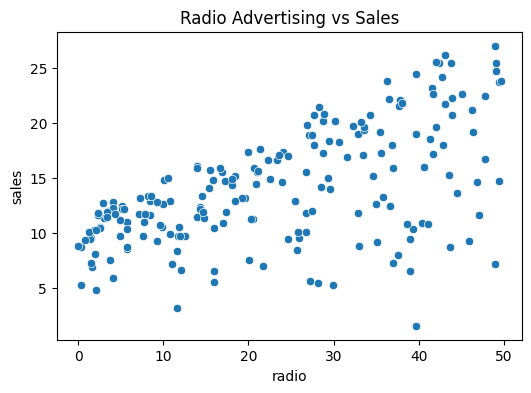

In [12]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='radio', y='sales', data=data)
plt.title('Radio Advertising vs Sales')
plt.show()

**Observation:**

- Radio advertising also shows a positive relationship with sales.
- The relationship is moderate compared to TV advertising.

### 9.4 Newspaper Advertising vs Sales

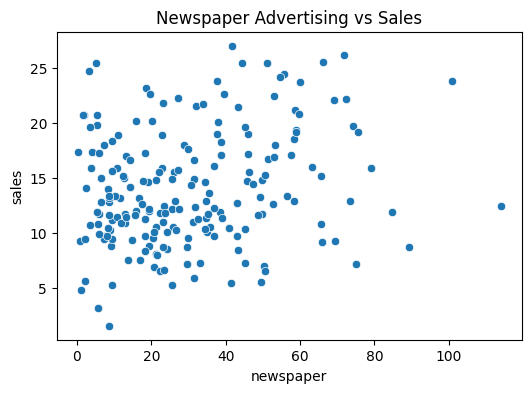

In [13]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='newspaper', y='sales', data=data)
plt.title('Newspaper Advertising vs Sales')
plt.show()

**Observation:**

- Newspaper advertising has a weak relationship with sales.
- Increasing newspaper advertising alone does not significantly improve sales.

### 9.5 Correlation Heatmap

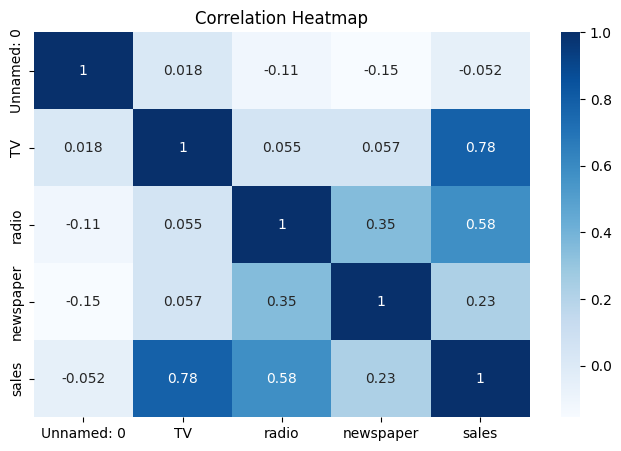

In [14]:
plt.figure(figsize=(8,5))
sns.heatmap(data.corr(), annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

**Observation:**

- TV has the strongest positive correlation with sales.
- Radio has a moderate positive correlation.
- Newspaper has the weakest correlation with sales.

## 10. Feature Selection

In [17]:
X = data[['TV', 'radio', 'newspaper']]
y = data['sales']

X.head()

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


## 11. Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (160, 3)
Testing data shape: (40, 3)


## 12. Model Building

In [19]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## 13. Model Prediction

In [20]:
y_pred = model.predict(X_test)

prediction = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
})

prediction.head(10)

,Actual Sales,Predicted Sales
95,16.9,16.408024
15,22.4,20.889882
30,21.4,21.553843
158,7.3,10.608503
128,24.7,22.112373
115,12.6,13.105592
69,22.3,21.057192
170,8.4,7.461010
174,11.5,13.606346
45,14.9,15.155070


## 14. Model Evaluation

In [21]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae,2))
print("Mean Squared Error (MSE):", round(mse,2))
print("Root Mean Squared Error (RMSE):", round(rmse,2))
print("R² Score:", round(r2,2))

Mean Absolute Error (MAE): 1.46
Mean Squared Error (MSE): 3.17
Root Mean Squared Error (RMSE): 1.78
R² Score: 0.9


**Observation:**

- The Linear Regression model predicts sales with good accuracy.
- A low MAE and RMSE indicate that the prediction errors are small.
- The R² score shows how well the model explains the variation in sales.
- Overall, the model performs well for predicting sales based on advertising expenditure.

## 15. Actual vs Predicted Sales

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

**Observation:**

- Most predicted values are close to the actual sales values.
- This indicates that the Linear Regression model fits the data well.

## 16. Conclusion

- Successfully built a Sales Prediction model using Linear Regression.
- Performed data preprocessing and exploratory data analysis.
- TV advertising showed the strongest influence on sales.
- Radio advertising had a moderate positive impact.
- Newspaper advertising had the least impact on sales.
- The model achieved good prediction accuracy with a high R² score.
- This model can help businesses optimize advertising budgets and improve sales forecasting.